In [2]:
import pandas as pd

In [3]:
from google .colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
df = pd.read_csv("insurance.csv")

In [5]:
print(df.head(10))

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14


In [6]:
print("shape:",df.shape)

shape: (1338, 7)


In [7]:
print("\nInformation:")
print(df.info())


Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [8]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000  16639.915000
max      64.000000    53.100000     5.000000  63770.430000


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


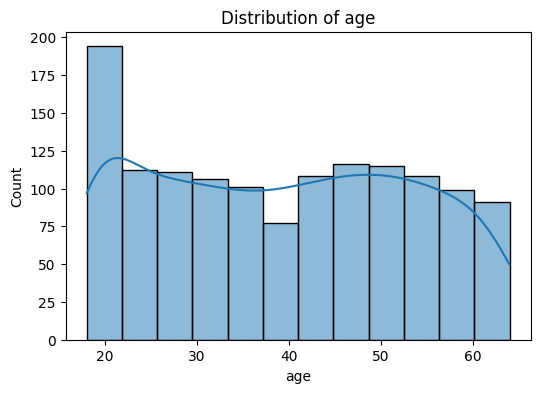

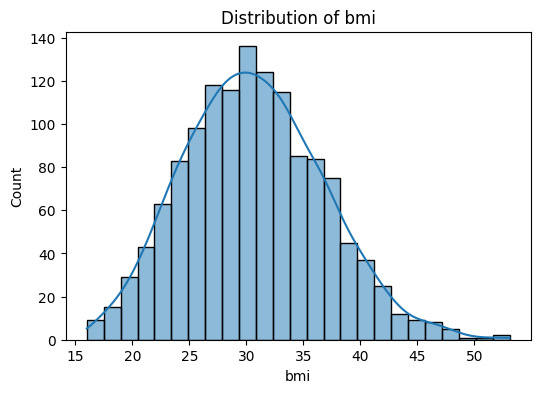

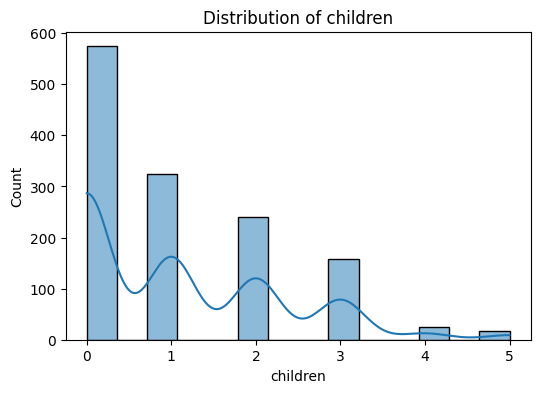

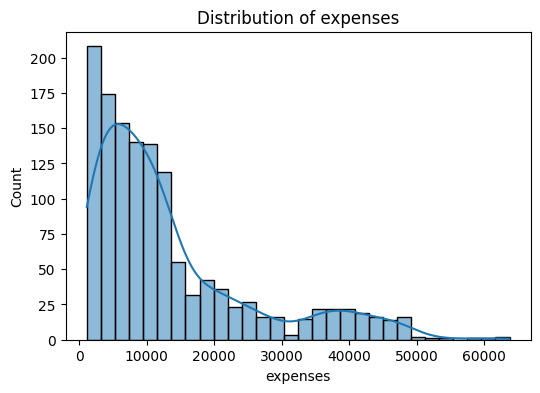

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = ['Age','BMI', 'Children', 'Charges']
num_cols = ['age','bmi', 'children', 'expenses']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

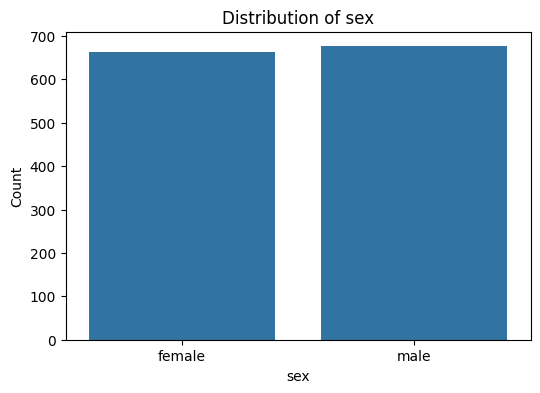

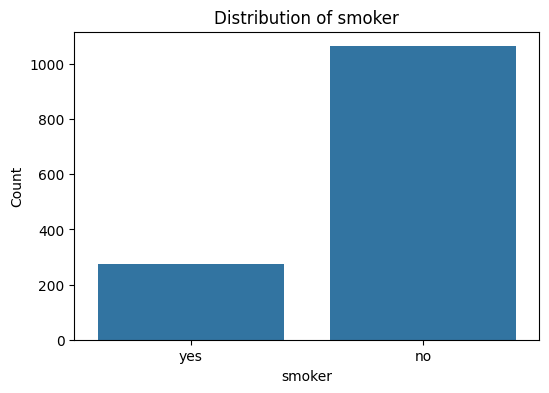

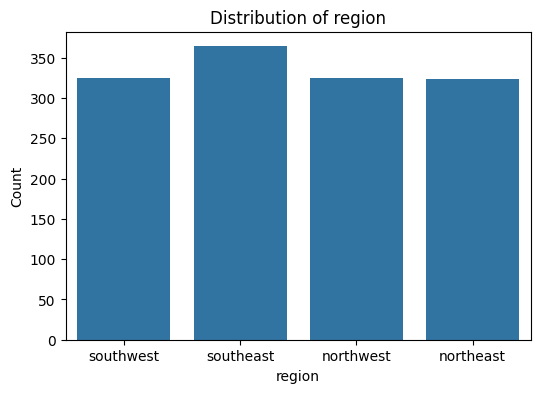

In [21]:
cat_cols =['sex','smoker','region']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

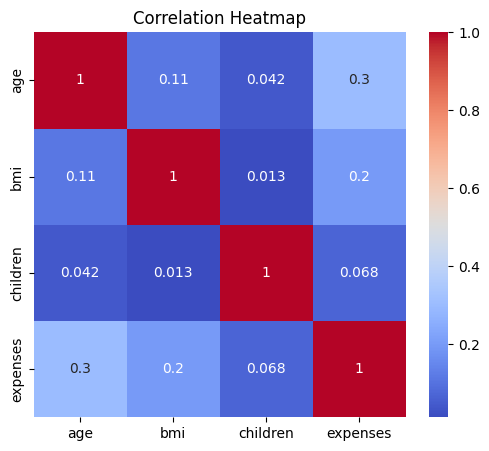

In [22]:
plt.figure(figsize=(6,5))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [29]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')


In [32]:
print("Average Expenses:", df['expenses'].mean())
print("Maximum Expenses:", df['expenses'].max())
print("Minimum Expenses:", df['expenses'].min())

print("\nAverage Expenses by Smoker:")
print(df.groupby('smoker')['expenses'].mean())

Average Expenses: 13270.422414050823
Maximum Expenses: 63770.43
Minimum Expenses: 1121.87

Average Expenses by Smoker:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


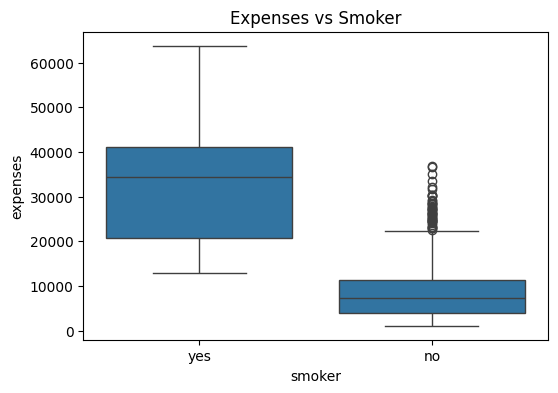

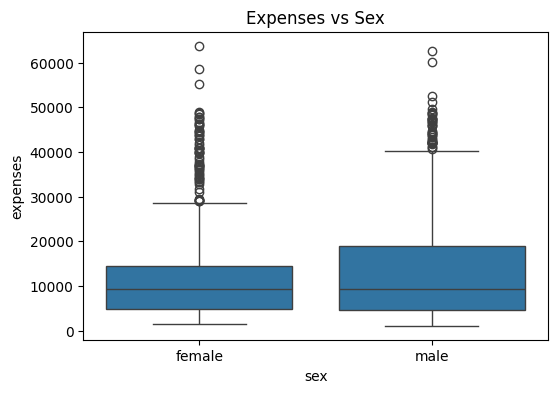

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title("Expenses vs Smoker")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='expenses', data=df)
plt.title("Expenses vs Sex")
plt.show()

In [36]:
print("Average Age:",df['age'].mean())

print("Average BMI:",df['bmi'].mean())

print(df['region'].value_counts())

Average Age: 39.20702541106129
Average BMI: 30.66547085201794
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
